In [1]:
!pip install earthengine-api cdsapi geopandas rasterio xarray rioxarray pandas numpy scikit-learn matplotlib


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import os

BASE="/content/drive/MyDrive/soil_degradation_project"

os.makedirs(BASE+"/raw",exist_ok=True)
os.makedirs(BASE+"/processed",exist_ok=True)


In [4]:
import ee
ee.Authenticate()
ee.Initialize(project= 'ndvi-489709')


In [5]:
"Définir la zone d'étude"
roi = ee.Geometry.Point([4.07,43.93]).buffer(5000)


In [7]:
"Calcul NDVI et NDWI"
def compute_indices(year):

    collection = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterDate(f"{year}-01-01", f"{year}-12-31")
        .filterBounds(roi)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
    )

    def add_indices(img):
        ndvi = img.normalizedDifference(['B8','B4']).rename('NDVI')
        ndwi = img.normalizedDifference(['B3','B8']).rename('NDWI')
        return img.addBands([ndvi, ndwi])

    collection = collection.map(add_indices)

    ndvi_mean = collection.select('NDVI').mean()
    ndwi_mean = collection.select('NDWI').mean()

    return ndvi_mean, ndwi_mean


In [8]:
"Extraire NDVI et NDWI par année"
import pandas as pd

for year in range(2016,2024):

    ndvi, ndwi = compute_indices(year)

    ndvi_val = ndvi.reduceRegion(
        reducer = ee.Reducer.mean(),
        geometry = roi,
        scale = 10,
        maxPixels = 1e9
    ).getInfo()

    ndwi_val = ndwi.reduceRegion(
        reducer = ee.Reducer.mean(),
        geometry = roi,
        scale = 10,
        maxPixels = 1e9
    ).getInfo()

    print(year, ndvi_val, ndwi_val)



2016 {'NDVI': 0.5858271067515727} {'NDWI': -0.5811205308936497}
2017 {'NDVI': 0.5647774746909249} {'NDWI': -0.5763955070737389}
2018 {'NDVI': 0.5582508119940068} {'NDWI': -0.5544973934887165}
2019 {'NDVI': 0.5546143351743955} {'NDWI': -0.5515026687186041}
2020 {'NDVI': 0.5697376740335757} {'NDWI': -0.5560639208112813}
2021 {'NDVI': 0.5796803833115105} {'NDWI': -0.5675674618809176}
2022 {'NDVI': 0.5538237022881068} {'NDWI': -0.5642021643986068}
2023 {'NDVI': 0.5696921374679627} {'NDWI': -0.5705695491784982}


In [9]:
"Initialisation Copernicus"
cds_config = """
url: https://cds.climate.copernicus.eu/api
key: 6a3d8389-1f82-417d-be74-93fd2c13367c
"""

# Écrire le fichier dans /root/.cdsapirc
with open("/root/.cdsapirc", "w") as f:
    f.write(cds_config)




In [56]:
"Humidité de sol - ERA5-Land - station proche Sommières est Villevieille"
" Extraire par tranche de 5 ans et par paramètre car fichier lourd - période 1993-2024"
import cdsapi
import os

output_dir = "/content/soil_moisture_era5/"
os.makedirs(output_dir, exist_ok=True)
c = cdsapi.Client()

years_batches = [(1993, 1997), (1998, 2002), (2003, 2007), (2008, 2012),
                 (2013, 2017), (2018, 2022), (2023, 2024)]
months = [f"{m:02d}" for m in range(1,13)]

for start, end in years_batches:
    years = [str(y) for y in range(start, end+1)]
    output_file = os.path.join(output_dir, f"soil_moisture_{start}_{end}.nc")
    if os.path.exists(output_file):
        print("Déjà téléchargé :", output_file)
        continue
    print("Téléchargement :", output_file)
    c.retrieve(
        'reanalysis-era5-land-monthly-means',
        {
            'variable':'volumetric_soil_water_layer_1',
            'year': years,
            'month': months,
            'time': '00:00',
            'format':'netcdf'
        },
        output_file
    )



Téléchargement : /content/soil_moisture_era5/soil_moisture_1993_1997.nc


2026-03-12 09:35:09,417 INFO Request ID is 8dfb0f51-617c-4e0e-b1d1-284a1e947c17
INFO:ecmwf.datastores.legacy_client:Request ID is 8dfb0f51-617c-4e0e-b1d1-284a1e947c17
2026-03-12 09:35:09,666 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-03-12 09:35:19,397 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-03-12 09:35:24,850 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


d4fc55385dac177656c7580f54c27d90.zip:   0%|          | 0.00/434M [00:00<?, ?B/s]

Téléchargement : /content/soil_moisture_era5/soil_moisture_1998_2002.nc


2026-03-12 09:39:46,340 INFO Request ID is 50d31218-f9b7-423d-a24b-6b3a03e08478
INFO:ecmwf.datastores.legacy_client:Request ID is 50d31218-f9b7-423d-a24b-6b3a03e08478
2026-03-12 09:39:47,309 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-03-12 09:40:01,726 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-03-12 09:40:09,554 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


...

2026-03-12 09:48:48,951 INFO Request ID is 3b038617-3c5f-4b42-b47d-66a3682a048b
INFO:ecmwf.datastores.legacy_client:Request ID is 3b038617-3c5f-4b42-b47d-66a3682a048b
2026-03-12 09:48:49,188 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-03-12 09:49:11,419 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


922918e524971dadc81ddaf3fdcc0eef.zip:   0%|          | 0.00/435M [00:00<?, ?B/s]

Téléchargement : /content/soil_moisture_era5/soil_moisture_2023_2024.nc


2026-03-12 09:49:51,132 INFO Request ID is 4182a3d7-a9d2-49a4-8cd4-7d543a2e4fdf
INFO:ecmwf.datastores.legacy_client:Request ID is 4182a3d7-a9d2-49a4-8cd4-7d543a2e4fdf
2026-03-12 09:49:51,376 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-03-12 09:50:05,807 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-03-12 09:50:13,640 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


59516556953149959060cc39ac55650c.zip:   0%|          | 0.00/174M [00:00<?, ?B/s]

In [11]:
# NON UTILISE ici
"Extraction fichier zip en format NetCDF"
import zipfile
import glob
import os
import xarray as xr
import pandas as pd

zip_folder = "/content/soil_moisture_era5"         # dossiers des zip .nc
output_csv = "/content/soil_moisture_1993_1999.csv"
tmp_extract = "/content/tmp_nc"
os.makedirs(tmp_extract, exist_ok=True)
# Supprimer ancien CSV si existe
if os.path.exists(output_csv):
    os.remove(output_csv)

zip_files = sorted(glob.glob(os.path.join(zip_folder, "*.zip")))  # Si ce sont des .zip

for zf in zip_files:
    print("Décompression de :", zf)
    with zipfile.ZipFile(zf, 'r') as zip_ref:
        zip_ref.extractall(tmp_extract)

    # Chercher le vrai .nc extrait
    nc_files = glob.glob(os.path.join(tmp_extract, "*.nc"))
    for nc in nc_files:
        print("Traitement de :", nc)
        try:
            # Ouvrir NetCDF via netCDF4 engine
            ds = xr.open_dataset(nc, engine="netcdf4")
            # Vérifier les variables
            print("Variables disponibles :", list(ds.data_vars))
            # Extraire uniquement la variable d'humidité du sol
            var_name = "swvl1"  # vérifier le nom exact dans ds.data_vars
            if var_name in ds.data_vars:
                # Traiter par chunks pour ne pas saturer la RAM
                for time_idx in range(len(ds.time)):
                    df = ds.isel(time=time_idx)[[var_name]].to_dataframe().reset_index()
                    df.to_csv(output_csv, mode='a', header=not os.path.exists(output_csv), index=False)
            ds.close()
        except Exception as e:
            print(f"Erreur avec {nc} :", e)
        finally:
            os.remove(nc)  # libérer espace et RAM

print("CSV final créé :", output_csv)

CSV final créé : /content/soil_moisture_1993_1999.csv


In [12]:
# Climat ERA5
import cdsapi
BASE="/content/drive/MyDrive/soil_degradation_project"
c=cdsapi.Client()

c.retrieve(
"reanalysis-era5-single-levels",
{
"variable":[
"2m_temperature",
"total_precipitation"
],
"product_type":"reanalysis",
"year":[str(y) for y in range(1993,2024)],
"month":[f"{m:02d}" for m in range(1,13)],
"day":["01"],
"time":["00:00"],
"format":"netcdf",
"area":[44.0,4.0,43.9,4.1]
},
BASE+"/raw/climate.nc"
)


2026-03-12 07:59:15,467 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
INFO:ecmwf.datastores.legacy_client:[2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-

d01b66d06e2276b672a5488f462e9783.zip:   0%|          | 0.00/100k [00:00<?, ?B/s]

'/content/drive/MyDrive/soil_degradation_project/raw/climate.nc'

In [24]:
# NON UTILISE ICI (sert à convertir fichiers .nc en csv)
!pip install netCDF4

import xarray as xr
import pandas as pd
import os
from google.colab import drive

# Monter Drive
drive.mount('/content/drive')

data_folder = "/content/drive/MyDrive/soil_degradation_project/raw/"

# Fichiers NetCDF réels
accum_file = data_folder + "data_stream-oper_stepType-accum.nc"
instant_file = data_folder + "data_stream-oper_stepType-instant.nc"

csv_file = data_folder + "climate_1993_2023.csv"

# Ouvrir les datasets
ds_accum = xr.open_dataset(accum_file, engine="netcdf4")
ds_instant = xr.open_dataset(instant_file, engine="netcdf4")

print("Variables accum :", list(ds_accum.data_vars))
print("Variables instant :", list(ds_instant.data_vars))

# Fusionner les datasets
ds = xr.merge([ds_accum, ds_instant])

# Convertir en dataframe
df = ds.to_dataframe().reset_index()

# Nettoyer
df = df.dropna()

# Sauvegarder CSV
df.to_csv(csv_file, index=False)

print("CSV créé :", csv_file)




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Variables accum : ['tp']
Variables instant : ['t2m']
CSV créé : /content/drive/MyDrive/soil_degradation_project/raw/climate_1993_2023.csv


/tmp/ipykernel_1199/3706564525.py:27: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge([ds_accum, ds_instant])
/tmp/ipykernel_1199/3706564525.py:27: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge([ds_accum, ds_instant])


In [27]:
# Occupation de sol (Copernicus)
def get_landcover(year):

    lc=ee.ImageCollection(
    "ESA/WorldCover/v100"
    ).first()

    value=lc.reduceRegion(
    reducer=ee.Reducer.mode(),
    geometry=roi,
    scale=10
    ).getInfo()["Map"]

    return value


In [28]:
 # Occupation de sol - extraction via Google Earth Engine (Copernicus)
landcover_values=[]

for year in years:

    lc=get_landcover(year)

    landcover_values.append(lc)

lc_df=pd.DataFrame({
"year":years,
"landcover":landcover_values
})

lc_df.to_csv(BASE+"/raw/landcover.csv",index=False)


In [75]:
# Prétraitement Climat
import xarray as xr
import pandas as pd

BASE="/content/drive/MyDrive/soil_degradation_project"

# Ouvrir les datasets
ds_temp = xr.open_dataset(BASE+"/raw/data_stream-oper_stepType-instant.nc")
ds_rain = xr.open_dataset(BASE+"/raw/data_stream-oper_stepType-accum.nc")

# Température moyenne annuelle
temp = ds_temp["t2m"].groupby("valid_time.year").mean()

# Conversion Kelvin → Celsius
temp = temp - 273.15

# Précipitations annuelles
rain = ds_rain["tp"].groupby("valid_time.year").sum()

# Moyenne spatiale (latitude / longitude)
temp_mean = temp.mean(dim=["latitude","longitude"])
rain_mean = rain.mean(dim=["latitude","longitude"])

# DataFrame
climate_df = pd.DataFrame({
    "year": temp_mean.year.values,
    "temperature": temp_mean.values,
    "precipitation": rain_mean.values
})

# Sauvegarde CSV
climate_df.to_csv(BASE+"/processed/climate_yearly.csv", index=False)

print("Fichier créé :", BASE+"/processed/climate_yearly.csv")


Fichier créé : /content/drive/MyDrive/soil_degradation_project/processed/climate_yearly.csv


In [3]:
# Prétraitement humidité de sol
import os
import zipfile
import xarray as xr
import pandas as pd
import shutil

# --------------------------
# 1️⃣ Dossiers
# --------------------------
BASE = "/content/drive/MyDrive/soil_degradation_project"
data_dir = "/content/soil_moisture_era5"
processed_dir = os.path.join(BASE, "processed")
extracted_dir = os.path.join(data_dir, "extracted")

os.makedirs(processed_dir, exist_ok=True)
os.makedirs(extracted_dir, exist_ok=True)

# --------------------------
# 2️⃣ Détecter et extraire les fichiers ZIP
# --------------------------
nc_files = sorted([os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith(".nc")])
extracted_files = []

for f in nc_files:
    try:
        with zipfile.ZipFile(f, 'r') as z:
            print(f"📦 ZIP détecté, extraction : {f}")
            z.extractall(extracted_dir)
            extracted_files.extend([os.path.join(extracted_dir, name) for name in z.namelist() if name.endswith(".nc")])
    except zipfile.BadZipFile:
        shutil.copy(f, extracted_dir)
        extracted_files.append(os.path.join(extracted_dir, os.path.basename(f)))

if len(extracted_files) == 0:
    raise FileNotFoundError("Aucun fichier NetCDF valide extrait !")

# --------------------------
# 3️⃣ Calcul moyenne annuelle fichier par fichier
# --------------------------
annual_data = []

for f in extracted_files:
    try:
        # Charger le fichier en mémoire partielle
        ds = xr.open_dataset(f, engine="netcdf4")

        # Détecter la dimension temps
        time_dim = [d for d in ds.dims if "time" in d][0]

        # Moyenne spatiale
        sm_mean = ds["swvl1"].mean(dim=["latitude","longitude"])

        # Moyenne annuelle
        sm_yearly = sm_mean.groupby(f"{time_dim}.year").mean().to_dataframe().reset_index()
        sm_yearly = sm_yearly.rename(columns={"swvl1":"soil_moisture"})

        annual_data.append(sm_yearly)
        ds.close()
        print("✅ Traité :", f)

    except Exception as e:
        print("⚠️ Ignoré :", f, e)

# --------------------------
# 4️⃣ Concaténer tous les résultats annuels
# --------------------------
soil_df = pd.concat(annual_data, ignore_index=True)

# Dans certains fichiers, il peut y avoir des années dupliquées → moyenne finale
soil_yearly = soil_df.groupby("year")["soil_moisture"].mean().reset_index()

# --------------------------
# 5️⃣ Sauvegarder CSV
# --------------------------
output_file = os.path.join(processed_dir, "soil_moisture_yearly.csv")
soil_yearly.to_csv(output_file, index=False)
print("✅ CSV annuel créé :", output_file)



📦 ZIP détecté, extraction : /content/soil_moisture_era5/soil_moisture_1993_1997.nc
📦 ZIP détecté, extraction : /content/soil_moisture_era5/soil_moisture_1998_2002.nc
📦 ZIP détecté, extraction : /content/soil_moisture_era5/soil_moisture_2003_2007.nc
📦 ZIP détecté, extraction : /content/soil_moisture_era5/soil_moisture_2008_2012.nc
📦 ZIP détecté, extraction : /content/soil_moisture_era5/soil_moisture_2013_2017.nc
📦 ZIP détecté, extraction : /content/soil_moisture_era5/soil_moisture_2018_2022.nc
📦 ZIP détecté, extraction : /content/soil_moisture_era5/soil_moisture_2023_2024.nc
✅ Traité : /content/soil_moisture_era5/extracted/data_stream-moda.nc
✅ Traité : /content/soil_moisture_era5/extracted/data_stream-mnth.nc
✅ Traité : /content/soil_moisture_era5/extracted/data_stream-moda.nc
✅ Traité : /content/soil_moisture_era5/extracted/data_stream-mnth.nc
✅ Traité : /content/soil_moisture_era5/extracted/data_stream-moda.nc
✅ Traité : /content/soil_moisture_era5/extracted/data_stream-mnth.nc
✅ Tra

In [15]:
# Fusion du dataset
import os
import pandas as pd
import rioxarray

# -------------------------------
# 1️⃣ Définir les chemins
# -------------------------------
BASE = "/content/drive/MyDrive"
processed_dir = os.path.join(BASE, "soil_degradation_project/processed")
os.makedirs(processed_dir, exist_ok=True)

soil_file = os.path.join(processed_dir, "soil_moisture_yearly.csv")
climate_file = os.path.join(processed_dir, "climate_yearly.csv")
landcover_file = os.path.join(BASE+"/soil_degradation_project/raw", "landcover.csv")
nd_folder = BASE  # là où sont les fichiers ndvi_*.tif et ndwi_*.tif

# -------------------------------
# 2️⃣ Charger les CSV climat, humidité de sol et landcover
# -------------------------------
soil_df = pd.read_csv(soil_file)
climate_df = pd.read_csv(climate_file)
landcover_df = pd.read_csv(landcover_file)

# -------------------------------
# 3️⃣ Traiter les fichiers NDVI / NDWI
# -------------------------------
ndvi_files = sorted([f for f in os.listdir(nd_folder) if f.startswith("ndvi") and f.endswith(".tif")])
ndwi_files = sorted([f for f in os.listdir(nd_folder) if f.startswith("ndwi") and f.endswith(".tif")])

nd_data = []

for ndvi_f, ndwi_f in zip(ndvi_files, ndwi_files):
    # Extraire l'année depuis le nom du fichier
    year = int(ndvi_f.split("_")[1])

    # Lire les raster et calculer la moyenne spatiale
    ndvi_path = os.path.join(nd_folder, ndvi_f)
    ndwi_path = os.path.join(nd_folder, ndwi_f)

    ndvi_mean = rioxarray.open_rasterio(ndvi_path).mean().item()
    ndwi_mean = rioxarray.open_rasterio(ndwi_path).mean().item()

    nd_data.append({"year": year, "NDVI": ndvi_mean, "NDWI": ndwi_mean})

nd_df = pd.DataFrame(nd_data).sort_values("year")
nd_df.to_csv(os.path.join(processed_dir, "nd_indices_yearly.csv"), index=False)
print("CSV NDVI/NDWI annuel créé :", os.path.join(processed_dir, "nd_indices_yearly.csv"))

# -------------------------------
# 4️⃣ Fusionner tous les datasets
# -------------------------------
merged_df = climate_df.merge(soil_df, on="year", how="left")
merged_df = merged_df.merge(nd_df, on="year", how="left")
merged_df = merged_df.merge(landcover_df, on="year", how="left")

# Sauvegarder le CSV final
final_csv = os.path.join(processed_dir, "final_dataset.csv")
merged_df.to_csv(final_csv, index=False)
print("CSV final fusionné créé :", final_csv)


CSV NDVI/NDWI annuel créé : /content/drive/MyDrive/soil_degradation_project/processed/nd_indices_yearly.csv
CSV final fusionné créé : /content/drive/MyDrive/soil_degradation_project/processed/final_dataset.csv


In [16]:
# Model Random Forest pour évaluer le risque de dégradation de sol
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
BASE="/content/drive/MyDrive/soil_degradation_project"
df=pd.read_csv(BASE+"/processed/final_dataset.csv")
X=df[[
"NDVI",
"NDWI",
"soil_moisture",
"temperature",
"precipitation",
"landcover"
]]

y=(df["NDVI"].diff()< -0.03).astype(int)

model=RandomForestClassifier(
n_estimators=200,
random_state=42
)

model.fit(X,y)

df["degradation_risk"]=model.predict(X)

df.to_csv(BASE+"/processed/soil_degradation_results.csv",index=False)


Colonnes dans le dataset : ['year', 'temperature', 'precipitation', 'soil_moisture', 'NDVI', 'NDWI', 'landcover']
    year  temperature  precipitation  soil_moisture      NDVI      NDWI  \
0   1993     9.169373       0.002255            NaN       NaN       NaN   
1   1994    13.289429       0.001450            NaN       NaN       NaN   
2   1995     9.618225       0.000124            NaN       NaN       NaN   
3   1996     9.920959       0.000958            NaN       NaN       NaN   
4   1997     8.864838       0.000270            NaN       NaN       NaN   
5   1998    10.765076       0.000891            NaN       NaN       NaN   
6   1999     9.852417       0.003458            NaN       NaN       NaN   
7   2000    10.338928       0.000391            NaN       NaN       NaN   
8   2001    11.652527       0.001459            NaN       NaN       NaN   
9   2002    10.251434       0.000315            NaN       NaN       NaN   
10  2003    12.264770       0.005272            NaN       NaN

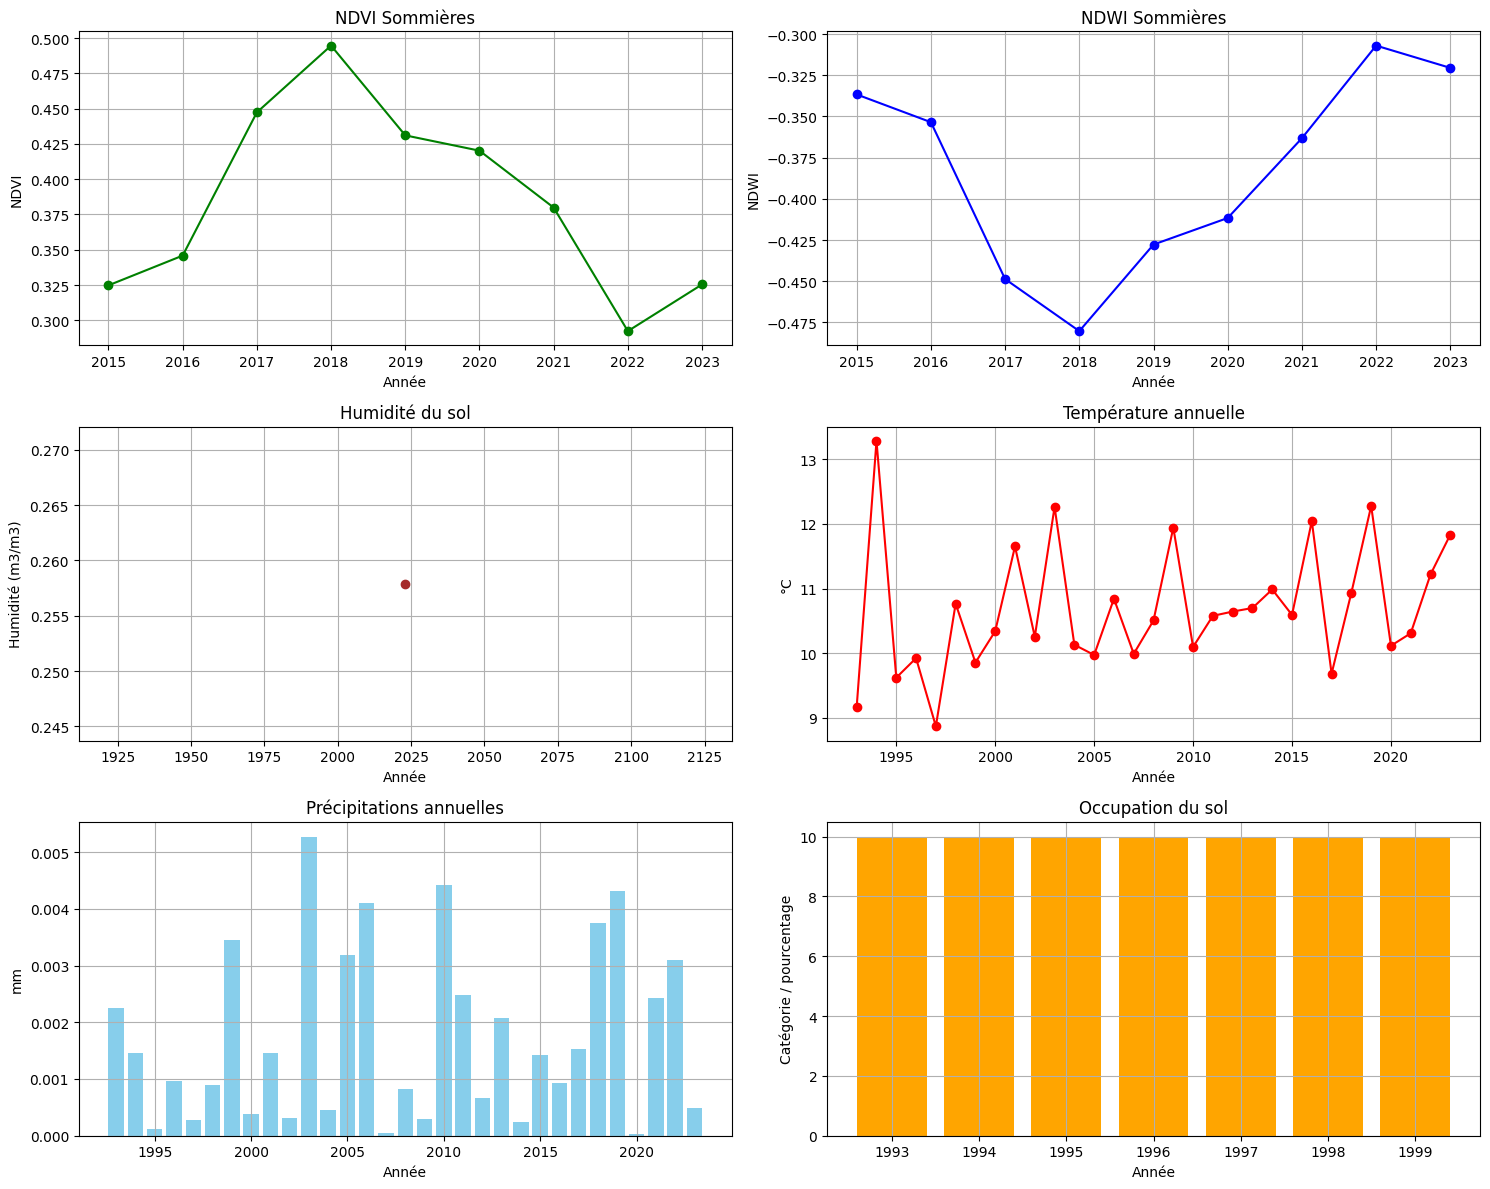

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# 1️⃣ Charger le CSV final
# -------------------------------
BASE = "/content/drive/MyDrive/soil_degradation_project/processed"
final_csv = f"{BASE}/final_dataset.csv"

df = pd.read_csv(final_csv)

# Vérifier les colonnes disponibles
print("Colonnes dans le dataset :", df.columns.tolist())
print(df)
# -------------------------------
# 2️⃣ Créer le graphique multi-panneaux
# -------------------------------
fig, axs = plt.subplots(3, 2, figsize=(15, 12))  # 3 lignes x 2 colonnes

# Placer les axes dans une liste pour faciliter l'accès
axes = axs.flatten()

# 2️⃣ NDVI
axes[0].plot(df['year'], df['NDVI'], marker='o', color='green', label='NDVI')
axes[0].set_title("NDVI Sommières")
axes[0].set_xlabel("Année")
axes[0].set_ylabel("NDVI")
axes[0].grid(True)

# 3️⃣ NDWI
axes[1].plot(df['year'], df['NDWI'], marker='o', color='blue', label='NDWI')
axes[1].set_title("NDWI Sommières")
axes[1].set_xlabel("Année")
axes[1].set_ylabel("NDWI")
axes[1].grid(True)

# 4️⃣ Humidité de sol
axes[2].plot(df['year'], df['soil_moisture'], marker='o', color='brown', label='Humidité sol')
axes[2].set_title("Humidité du sol")
axes[2].set_xlabel("Année")
axes[2].set_ylabel("Humidité (m3/m3)")
axes[2].grid(True)

# 5️⃣ Température
axes[3].plot(df['year'], df['temperature'], marker='o', color='red', label='Température')
axes[3].set_title("Température annuelle")
axes[3].set_xlabel("Année")
axes[3].set_ylabel("°C")
axes[3].grid(True)

# 6️⃣ Précipitations
axes[4].bar(df['year'], df['precipitation'], color='skyblue', label='Précipitations')
axes[4].set_title("Précipitations annuelles")
axes[4].set_xlabel("Année")
axes[4].set_ylabel("mm")
axes[4].grid(True)

# 7️⃣ Landcover (si catégorie numérique ou pourcentage)
if 'landcover' in df.columns:
    axes[5].bar(df['year'], df['landcover'], color='orange', label='Occupation sol')
    axes[5].set_title("Occupation du sol")
    axes[5].set_xlabel("Année")
    axes[5].set_ylabel("Catégorie / pourcentage")
    axes[5].grid(True)
else:
    axes[5].text(0.5, 0.5, 'Landcover non disponible', horizontalalignment='center', verticalalignment='center', transform=axes[5].transAxes)
    axes[5].set_title("Occupation du sol")
    axes[5].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# Supprimer les données brutes
import shutil

shutil.rmtree(BASE+"/raw")
